In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
column_names = ['train_data_size', 'val_data_size', 'random_seed', 'representation', 
                'train_accuracy', 'val_accuracy', 'test_accuracy', 'num_epochs', 'batch_size']

In [4]:
df = pd.read_csv('../results/dvs128_cnn_01_to_09_batch8_3seeds.txt', names=column_names, skiprows=1)


In [5]:
df.head()

,train_data_size,val_data_size,random_seed,representation,train_accuracy,val_accuracy,test_accuracy,num_epochs,batch_size
0,0.1,0.1,13,binary,0.614583,0.399194,0.530303,9,8
1,0.1,0.1,13,n_bins,0.621528,0.387097,0.458333,9,8
2,0.1,0.1,13,spike_count,0.752315,0.528614,0.590909,13,8
3,0.1,0.1,13,timesurface,0.555556,0.453125,0.537879,9,8
4,0.1,0.1,13,time_window,0.815972,0.603409,0.651515,17,8


In [6]:
grouped_data = df.groupby(['train_data_size', 'representation']).agg({
    'train_accuracy': 'mean',
    'val_accuracy': 'mean',
    'test_accuracy': 'mean'
}).reset_index()

In [7]:
grouped_data.head()

,train_data_size,representation,train_accuracy,val_accuracy,test_accuracy
0,0.1,binary,0.655093,0.465032,0.545455
1,0.1,n_bins,0.636445,0.417027,0.489899
2,0.1,spike_count,0.730813,0.540522,0.606061
3,0.1,time_window,0.708333,0.536702,0.631313
4,0.1,timesurface,0.642824,0.497195,0.590909


In [8]:
grouped_data.tail()

,train_data_size,representation,train_accuracy,val_accuracy,test_accuracy
40,0.9,binary,0.900945,0.785061,0.847222
41,0.9,n_bins,0.879049,0.753108,0.844697
42,0.9,spike_count,0.928686,0.915422,0.900253
43,0.9,time_window,0.916043,0.903687,0.877525
44,0.9,timesurface,0.913899,0.907372,0.882576


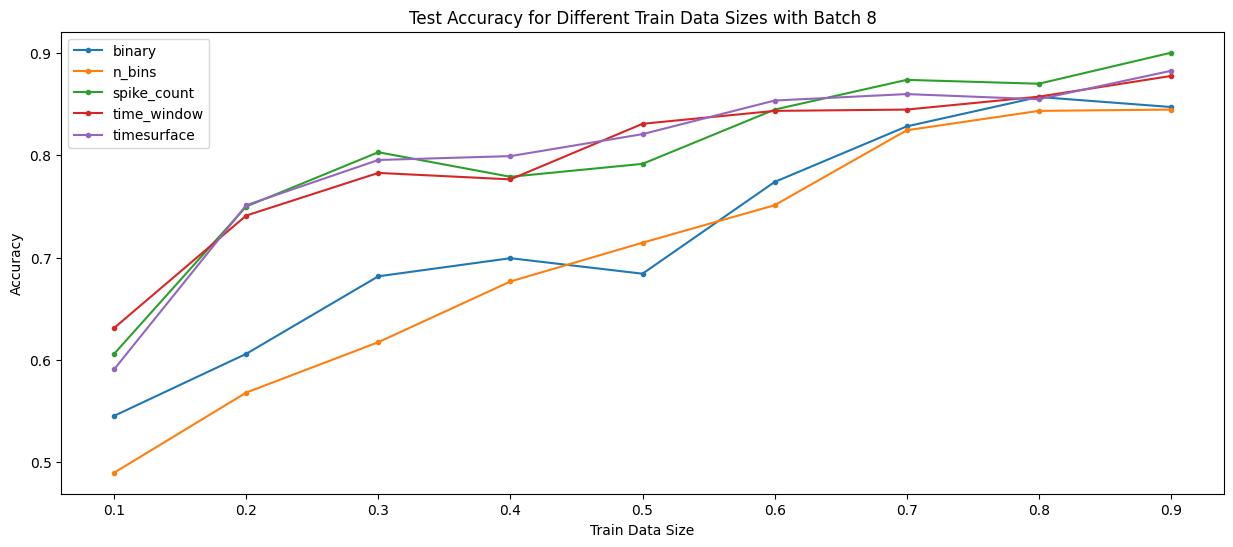

In [80]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))
# ax.set_facecolor(color='white', )
fig.patch.set_alpha(0.0)
ax.grid(color='white')

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_data_size'], rep_data['test_accuracy'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Accuracy')
plt.title('Test Accuracy for Different Train Data Sizes with Batch 8')
plt.legend()
plt.show()

In [13]:
df2 = pd.read_csv('../results/dvs128_cnn_09_batch8_10seeds.txt')

In [14]:
df2.head()

,train_data_size,val_data_size,random_seed,representation,train_acc,val_acc,test_acc,num_epochs,batch_size
0,0.9,0.1,13,binary,0.878093,0.741870,0.893939,9,8
1,0.9,0.1,13,n_bins,0.833849,0.672727,0.795455,7,8
2,0.9,0.1,13,spike_count,0.953233,0.925398,0.893939,23,8
3,0.9,0.1,13,timesurface,0.923490,0.862745,0.890152,15,8
4,0.9,0.1,13,time_window,0.885052,0.831081,0.840909,9,8


In [62]:
df2['num_epochs'] = df2['num_epochs'] + 1

grouped_data2 = df2.groupby(['representation']).agg({
    'train_acc': ['mean', 'std'],
    'val_acc': ['mean', 'std'],
    'test_acc': ['mean', 'std'],
    'num_epochs': 'mean',
}).reset_index()

In [63]:
grouped_data2.head()

representation train_acc             val_acc            test_acc            \
                      mean       std      mean       std      mean       std   
0         binary  0.811629  0.270250  0.713165  0.248278  0.777357  0.258006   
1         n_bins  0.858962  0.066117  0.730356  0.067616  0.820707  0.034405   
2    spike_count  0.899908  0.025995  0.875963  0.036387  0.874158  0.033762   
3    time_window  0.916770  0.023423  0.881985  0.026042  0.884680  0.029102   
4    timesurface  0.903622  0.027081  0.889735  0.020772  0.883838  0.029034   

  num_epochs  
        mean  
0  14.000000  
1  11.333333  
2  12.888889  
3  14.888889  
4  14.444444

C:\Users\osvat\AppData\Local\Temp\ipykernel_21900\1836722116.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


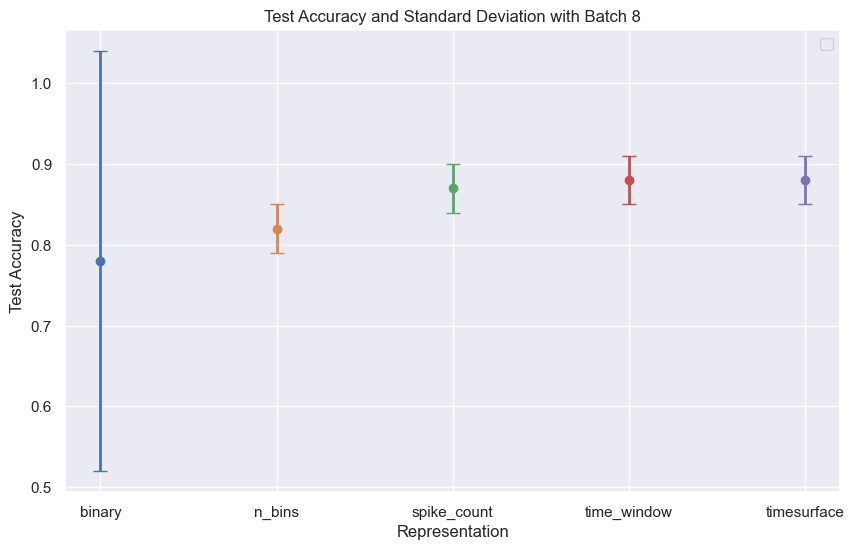

In [78]:

fig, ax = plt.subplots(figsize=(10, 6))

for rep in grouped_data2['representation'].unique():
    rep_data = grouped_data2[grouped_data2['representation'] == rep]
    ax.errorbar(rep, 
                rep_data['test_acc']['mean'],
                yerr=rep_data['test_acc']['std'],
                marker='o', 
                linewidth=2,
                capsize=5)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy and Standard Deviation with Batch 8')
ax.legend()

C:\Users\osvat\AppData\Local\Temp\ipykernel_21900\2280797234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_21900\2280797234.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


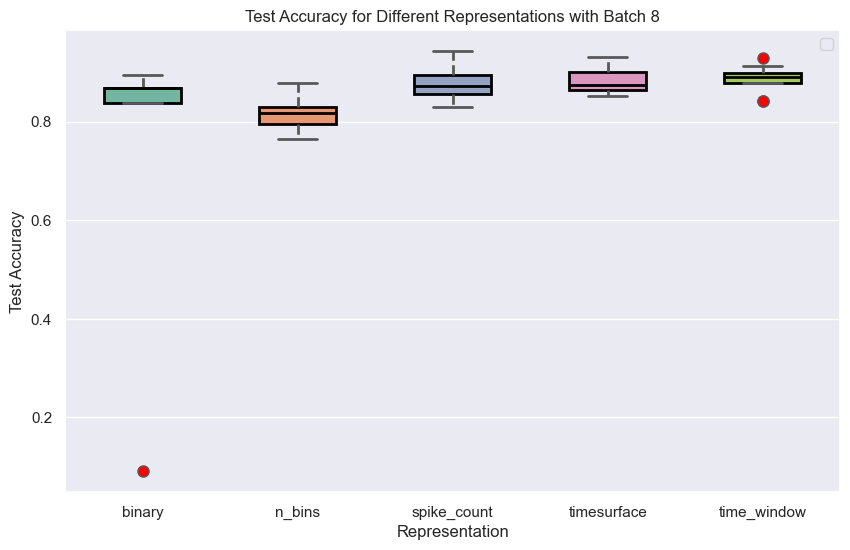

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df2, 
    x="representation", 
    y="test_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy for Different Representations with Batch 8')
ax.legend()

In [66]:
grouped_data2 = grouped_data2.round(2)
grouped_data2.to_csv('./dvs128_cnn_09_batch8_10seeds_grouped.csv', index=False)